# Clase 4

Una red neuronal no se define solo por su arquitectura, sino también por **cómo se entrena**.  
Para encontrar la mejor configuración usamos `RandomizedSearchCV`, explorando:

- Número de neuronas en la capa oculta  
- Función de activación  
- Learning rate  
- Optimizador (Adam vs SGD)  
- Regularización L2 (`alpha`)  
- Tamaño de batch  
- Early stopping  

Esto permitió maximizar el AUC en validación cruzada y reducir el riesgo de sobreajuste.


In [14]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, log_loss

from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

# 1. Datos usados en Clase 3

In [ ]:
X, y = fetch_openml(name="diabetes", version=1, as_frame=True, return_X_y=True)
y = y.map({"tested_negative": 0, "tested_positive": 1}).astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [16]:
print(X_train.shape, X_val.shape)


(576, 8) (192, 8)


# 2. Optimización de hiperparámetros con RandomizedSearchCV

* **Qué buscamos**: configuraciones que mejoren generalización (no solo train).
* **Optimizaremos**: tamaño de capa oculta, activación, alpha (L2), learning rate, solver, batch size.

In [5]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        max_iter=800,
        random_state=42
    ))
])

param_dist = {
    "mlp__hidden_layer_sizes": [(2,), (4,), (8,), (16,), (8,4)],
    "mlp__activation": ["relu", "tanh", "logistic"],
    "mlp__alpha": np.logspace(-6, -1, 10),            # L2 strength (regularización)
    "mlp__learning_rate_init": np.logspace(-4, -1, 8),
    "mlp__solver": ["adam", "sgd"],
    "mlp__batch_size": [16, 32, 64, 128],
    # early stopping en el tuning también:
    "mlp__early_stopping": [True],
    "mlp__n_iter_no_change": [10, 20],
    "mlp__validation_fraction": [0.1, 0.2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best AUC CV:", search.best_score_)
print("Best params:", search.best_params_)
best_model = search.best_estimator_


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best AUC CV: 0.8257739837398373
Best params: {'mlp__validation_fraction': 0.1, 'mlp__solver': 'sgd', 'mlp__n_iter_no_change': 10, 'mlp__learning_rate_init': 0.1, 'mlp__hidden_layer_sizes': (2,), 'mlp__early_stopping': True, 'mlp__batch_size': 16, 'mlp__alpha': 1e-06, 'mlp__activation': 'logistic'}


* Evaluación en validación (holdout):

In [6]:
p_val = best_model.predict_proba(X_val)[:, 1]
print("VAL AUC:", roc_auc_score(y_val, p_val))
print("VAL LogLoss:", log_loss(y_val, np.clip(p_val, 1e-6, 1-1e-6)))
print("VAL Accuracy:", accuracy_score(y_val, (p_val>=0.5).astype(int)))


VAL AUC: 0.8327164179104477
VAL LogLoss: 0.483119771077216
VAL Accuracy: 0.7447916666666666


# 3. Diagnóstico underfitting vs overfitting con Curvas de Aprendizaje

Idea clave:

* Si train y valid están bajos y pegados ⇒ underfitting (modelo muy simple / demasiada regularización).

* Si train alto pero valid bajo ⇒ overfitting (modelo complejo / poca regularización / falta data).

* Si ambos altos y cercanos ⇒ buen bias-variance.

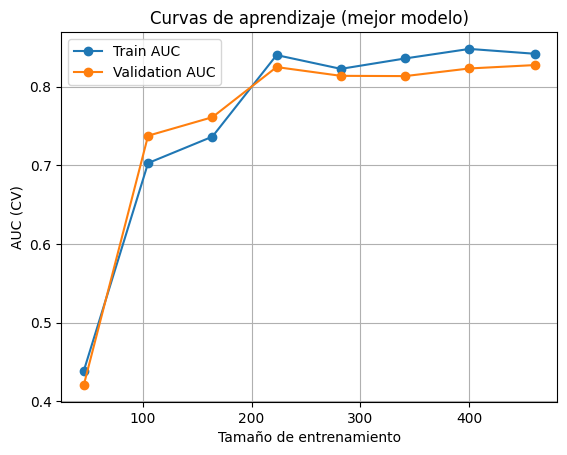

In [7]:
def plot_learning_curves(estimator, X, y, title="Learning Curves"):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X, y,
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, marker="o")
    plt.plot(train_sizes, val_mean, marker="o")
    plt.xlabel("Tamaño de entrenamiento")
    plt.ylabel("AUC (CV)")
    plt.title(title)
    plt.legend(["Train AUC", "Validation AUC"])
    plt.grid(True)
    plt.show()

plot_learning_curves(best_model, X_train, y_train, title="Curvas de aprendizaje (mejor modelo)")


# 4. Regularización L2 y L1

En sklearn MLP, la regularización expuesta es ``L2`` (parámetro ``alpha``). Ya la estás optimizando arriba.

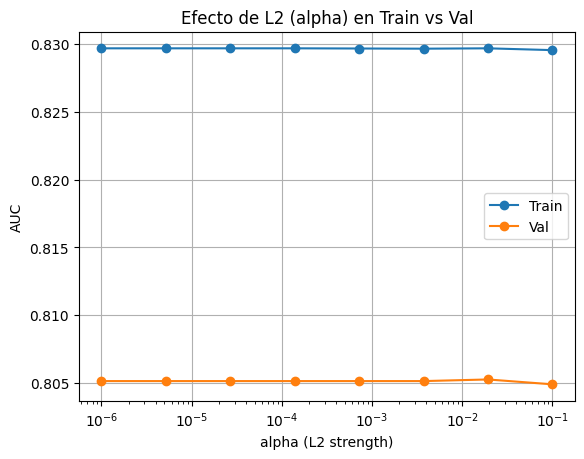

In [8]:
alphas = np.logspace(-6, -1, 8)
train_auc = []
val_auc = []

for a in alphas:
    m = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=(8,),
                              activation="relu",
                              solver="adam",
                              alpha=a,
                              learning_rate_init=0.01,
                              early_stopping=True,
                              n_iter_no_change=20,
                              max_iter=800,
                              random_state=42))
    ])
    m.fit(X_train, y_train)
    p_tr = m.predict_proba(X_train)[:,1]
    p_va = m.predict_proba(X_val)[:,1]
    train_auc.append(roc_auc_score(y_train, p_tr))
    val_auc.append(roc_auc_score(y_val, p_va))

plt.figure()
plt.semilogx(alphas, train_auc, marker="o")
plt.semilogx(alphas, val_auc, marker="o")
plt.xlabel("alpha (L2 strength)")
plt.ylabel("AUC")
plt.title("Efecto de L2 (alpha) en Train vs Val")
plt.legend(["Train", "Val"])
plt.grid(True)
plt.show()


**L1 (no directo) en MLPClassifier**

El MLP de sklearn no soporta L1 en sus pesos.
Si te piden ``L1 vs L2`` como concepto, una forma 100% sklearn es incluir un baseline de clasificación lineal con L1/L2 (logistic con SGD o LogisticRegression) y compararlo con tu MLP (L2).

In [10]:
from sklearn.linear_model import LogisticRegression

log_l2 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(penalty="l2", solver="liblinear", max_iter=2000))
])

log_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000))
])

log_l2.fit(X_train, y_train)
log_l1.fit(X_train, y_train)

p_l2 = log_l2.predict_proba(X_val)[:,1]
p_l1 = log_l1.predict_proba(X_val)[:,1]

print("LogReg L2 AUC:", roc_auc_score(y_val, p_l2))
print("LogReg L1 AUC:", roc_auc_score(y_val, p_l1))
print("MLP (best) AUC:", roc_auc_score(y_val, p_val))


LogReg L2 AUC: 0.8318805970149253
LogReg L1 AUC: 0.8310447761194031
MLP (best) AUC: 0.8327164179104477


# 5. Early Stopping 

In [11]:
mlp = best_model.named_steps["mlp"]
print("Iteraciones reales (n_iter_):", mlp.n_iter_)
print("Loss final:", mlp.loss_)


Iteraciones reales (n_iter_): 15
Loss final: 0.4566893832426823


En **MLPClassifier**, ``n_iter_`` es el número de épocas/iteraciones de entrenamiento efectivamente ejecutadas (pasadas completas por los datos) antes de detenerse.

Con ``early_stopping=True``, el modelo separa internamente una fracción del train como validación (por defecto ``validation_fraction=0.1``) y se detiene cuando la métrica de validación deja de mejorar durante n_iter_no_change iteraciones (por defecto 10; tú a veces la dejaste en 20).

Entonces, que pare en 15 suele significar:

* la validación dejó de mejorar temprano, o

* el modelo está bien regularizado y llega rápido a su “mejor punto”, o

* el ``learning_rate_init`` es relativamente alto y converge rápido.

# 6. Empaquetado del modelo final

* Guardar el Modelo

In [12]:
import pickle

# Guardar el modelo optimizado (Pipeline completo: scaler + MLP)
with open("mlp_diabetes_best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Modelo guardado como mlp_diabetes_best_model.pkl")


Modelo guardado como mlp_diabetes_best_model.pkl


* Cargar el modelo

In [13]:
# Cargar modelo
with open("mlp_diabetes_best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Usar el modelo cargado
p_loaded = loaded_model.predict_proba(X_val)[:, 1]

from sklearn.metrics import roc_auc_score, accuracy_score
print("AUC cargado:", roc_auc_score(y_val, p_loaded))
print("Accuracy cargado:", accuracy_score(y_val, (p_loaded >= 0.5).astype(int)))


AUC cargado: 0.8327164179104477
Accuracy cargado: 0.7447916666666666
